In [5]:
!pip install torch torchvision

  Using cached torch-2.4.1-cp38-cp38-win_amd64.whl.metadata (27 kB)
  Using cached torchvision-0.19.1-cp38-cp38-win_amd64.whl.metadata (6.1 kB)
  Using cached filelock-3.16.1-py3-none-any.whl.metadata (2.9 kB)
  Using cached sympy-1.13.3-py3-none-any.whl.metadata (12 kB)
  Using cached fsspec-2025.3.0-py3-none-any.whl.metadata (11 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
Using cached torch-2.4.1-cp38-cp38-win_amd64.whl (199.4 MB)
Using cached torchvision-0.19.1-cp38-cp38-win_amd64.whl (1.3 MB)
Using cached filelock-3.16.1-py3-none-any.whl (16 kB)
Using cached fsspec-2025.3.0-py3-none-any.whl (193 kB)
Using cached sympy-1.13.3-py3-none-any.whl (6.2 MB)
Using cached mpmath-1.3.0-py3-none-any.whl (536 kB)


In [6]:
import torch
import numpy as np
import matplotlib.pyplot as plt
rng = np.random

In [7]:
# Parameters.
learning_rate = 0.01
training_steps = 1000
display_step = 50

In [8]:
# Xây dựng dữ liệu
X = np.array([3.3,4.4,5.5,6.71,6.93,4.168,9.779,6.182,7.59,2.167,
              7.042,10.791,5.313,7.997,5.654,9.27,3.1])
Y = np.array([1.7,2.76,2.09,3.19,1.694,1.573,3.366,2.596,2.53,1.221,
              2.827,3.465,1.65,2.904,2.42,2.94,1.3])

In [9]:
inputs = torch.from_numpy(X)
targets = torch.from_numpy(Y)

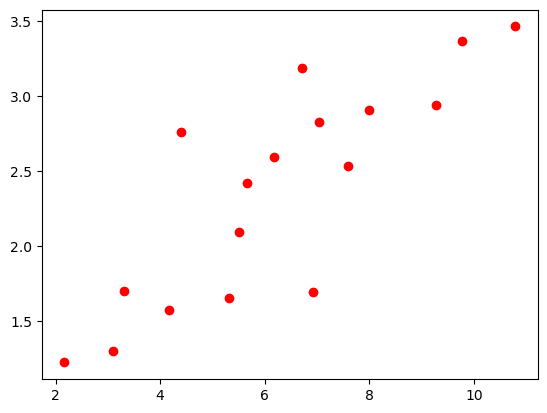

In [10]:
# Trực quan hóa dữ liệu
plt.plot(X, Y, 'ro', label='Original data')
plt.show()

In [11]:
# Xây dựng hàm hồi quy (Wx + b).
def model(x):
    return x * w + b

In [12]:
# Khởi tạo giá trị trọng số W và bias
w = torch.randn(1, requires_grad=True)
b = torch.randn(1, requires_grad=True)

In [13]:
# Xây dựng hàm mất mát (loss function)

# MSE loss
def mse(t1, t2):
    diff = t1 - t2
    return torch.sum(diff * diff) / diff.numel()

In [14]:
preds = model(inputs)
preds

tensor([ 0.0964,  0.1925,  0.2887,  0.3944,  0.4137,  0.1722,  0.6627,  0.3483,
         0.4714, -0.0027,  0.4235,  0.7512,  0.2723,  0.5069,  0.3021,  0.6182,
         0.0789], dtype=torch.float64, grad_fn=<AddBackward0>)

In [15]:
# in giá trị loss khi chưa xảy ra quá trình học
loss = mse(preds, targets)
loss

tensor(4.3573, dtype=torch.float64, grad_fn=<DivBackward0>)

In [16]:
# Compute gradients
loss.backward()

In [17]:
w.grad

tensor([-26.8890])

In [18]:
# thay đổi giá trị weights và reset lại gradient
with torch.no_grad():
    w -= w.grad * learning_rate
    b -= b.grad * learning_rate
    w.grad.zero_()
    b.grad.zero_()

In [19]:
# in giá trị loss sau khi xảy ra quá trình học (cập nhật trọng số)
y_pred_after_train = model(inputs)
y_pred_after_train
loss = mse(targets, y_pred_after_train)
loss

tensor(0.3031, dtype=torch.float64, grad_fn=<DivBackward0>)

In [20]:
print(w, b)

tensor([0.3563], requires_grad=True) tensor([-0.1518], requires_grad=True)


In [21]:
# Huấn luyện mô hình với training_steps đã được xác định từ trước
losses = []
for i in range(training_steps):
    preds = model(inputs)
    loss = mse(preds, targets)
    losses.append(loss)
    loss.backward()
    with torch.no_grad():
        w -= w.grad * learning_rate
        b -= b.grad * learning_rate
        w.grad.zero_()
        b.grad.zero_()

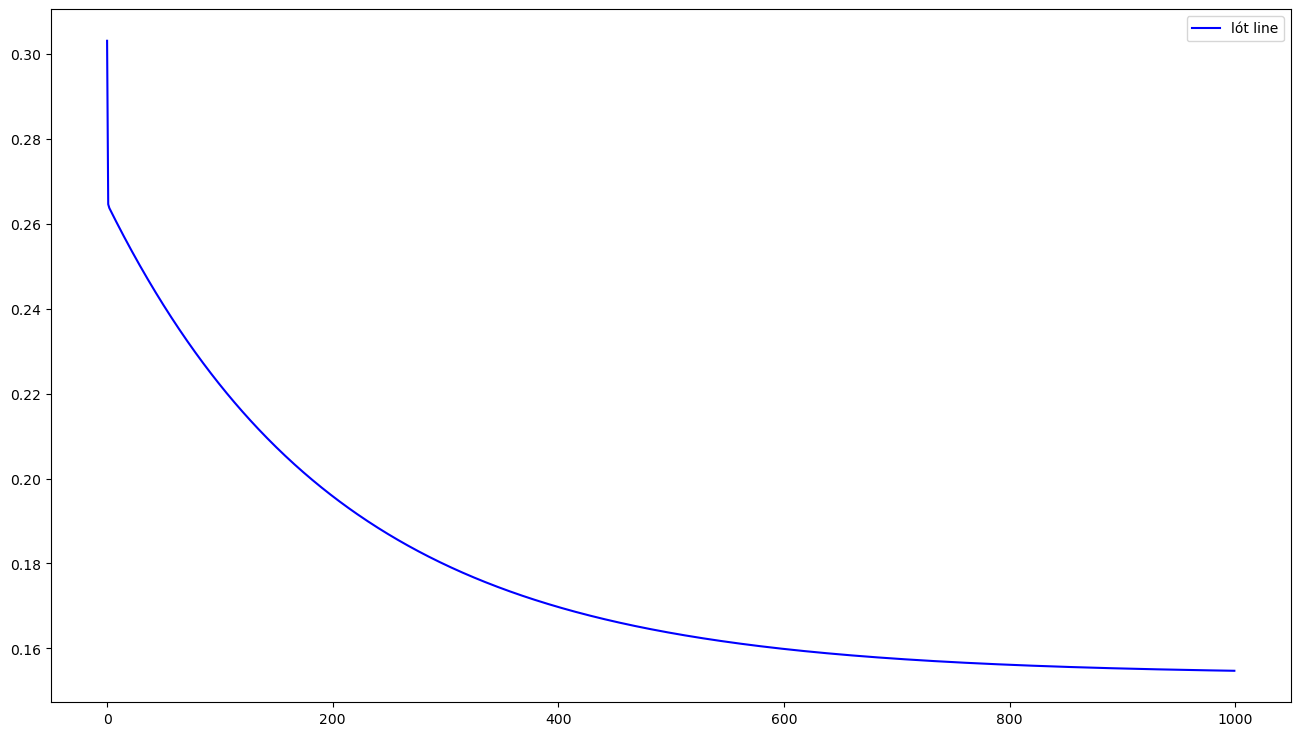

In [23]:
losses_in_list = [i.detach().item() for i in losses]
plt.figure(figsize = (16,9))
plt.plot(range(len(losses_in_list)), losses_in_list, color = 'b', label = 'lót line')
plt.legend(loc = 'best')
plt.show()

In [24]:
import matplotlib.pyplot as plt

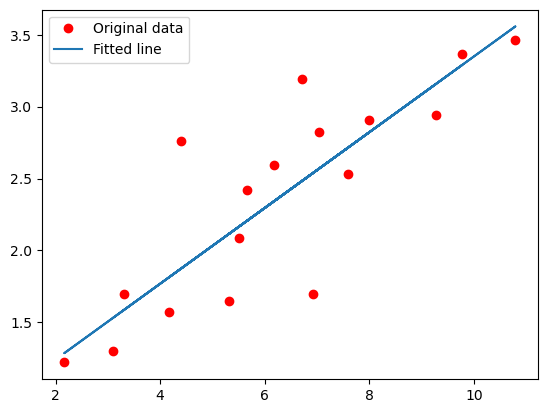

In [26]:
# Mô hình hóa sự tương quan giữa những điểm dữ liệu và phương trình tuyến tính
plt.plot(X, Y, 'ro', label='Original data')
plt.plot(X, (w * inputs + b).detach().numpy(), label='Fitted line')
plt.legend()
plt.show()